In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os # import os module to list directory content
import pandas as pd # import pandas to read the csv
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Download latest version
path = kagglehub.dataset_download("rabieelkharoua/alzheimers-disease-dataset")

print("Path to dataset files:", path)

# List the content of the downloaded directory to identify the data file
files = os.listdir(path) # print the list of files
print(files)

# Search for the CSV file
csv_file = next((f for f in files if f.endswith(".csv")), None)

full_file_path = os.path.join(path, csv_file)
    # Use pandas to read the CSV file directly
df = pd.read_csv(full_file_path) # Read the file using pandas

Path to dataset files: /kaggle/input/alzheimers-disease-dataset
['alzheimers_disease_data.csv']


# Exploratory Data Analysis (EDA)

***Alzheimer's Disease Dataset:***

In [ ]:
# let's look at the first few instances
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
df.shape

(2149, 35)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [ ]:
df.describe(include='all')

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XXXConfid
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2149
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653,NaN
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214,NaN
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,NaN


In [ ]:
# Check Unique Values
df.nunique()
df = df.drop('PatientID', axis=1)

In [ ]:
# Check for missing values
df.isnull().sum()

,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0
SleepQuality,0


In [ ]:
#check the cat and num column name
cat_cols=df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
['DoctorInCharge']
Numerical Variables:
['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']


In [ ]:
import pandas as pd
# One-Hot Encode the 'DoctorInCharge' column
df_encoded = pd.get_dummies(df, columns=['DoctorInCharge'], drop_first=True)

# Check the result
print(df_encoded.head())


   Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0   73       0          0               2  22.927749        0   
1   89       0          0               0  26.827681        0   
2   73       0          3               1  17.795882        0   
3   74       1          0               1  33.800817        1   
4   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
0           13.297218          6.327112     1.347214      9.025679  ...   
1            4.542524          7.619885     0.518767      7.151293  ...   
2           19.555085          7.844988     1.826335      9.673574  ...   
3           12.209266          8.428001     7.435604      8.392554  ...   
4           18.454356          6.310461     0.795498      5.597238  ...   

   FunctionalAssessment  MemoryComplaints  BehavioralProblems       ADL  \
0              6.518877                 0                   0  1.725883   
1       

In [ ]:
from sklearn.preprocessing import StandardScaler

# Define the numerical columns that you want to scale
num_cols = ['Age', 'BMI', 'SystolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to the numerical columns
df[num_cols] = scaler.fit_transform(df[num_cols])

# Check the first few rows to confirm the scaling
print(df.head())


        Age  Gender  Ethnicity  EducationLevel       BMI  Smoking  \
0 -0.212368       0          0               2 -0.655225        0   
1  1.567757       0          0               0 -0.114751        0   
2 -0.212368       0          3               1 -1.366428        0   
3 -0.101111       1          0               1  0.851625        1   
4  1.567757       0          0               0 -0.961607        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  SleepQuality  ...  \
0           13.297218          6.327112     1.347214      9.025679  ...   
1            4.542524          7.619885     0.518767      7.151293  ...   
2           19.555085          7.844988     1.826335      9.673574  ...   
3           12.209266          8.428001     7.435604      8.392554  ...   
4           18.454356          6.310461     0.795498      5.597238  ...   

   MemoryComplaints  BehavioralProblems       ADL  Confusion  Disorientation  \
0                 0                   0 -1.104434     

Diagnosis
0    1389
1     760
Name: count, dtype: int64


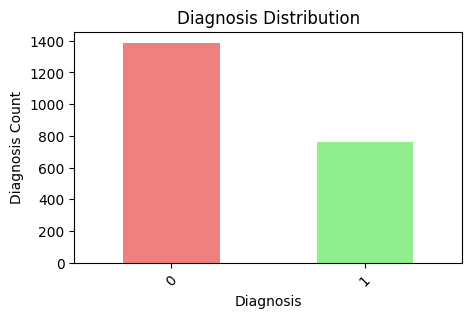

In [ ]:
# Visualize the distribution of the 'Diagnosis' variable

print(df.value_counts('Diagnosis'))

plt.figure(figsize=(5, 3))
df['Diagnosis'].value_counts().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Diagnosis Count')
plt.xticks(rotation = 45)
plt.show()


Ethnicity
0    1278
1     454
2     206
3     211
Name: count, dtype: int64


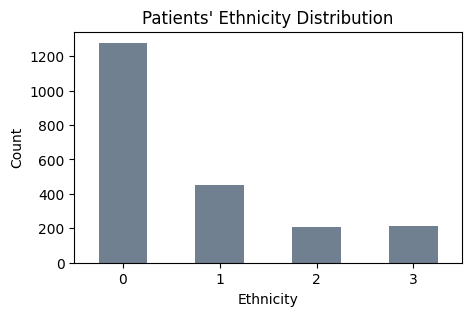

In [ ]:
# Visualize the distribution of 'Ethnicity' variable
print(df.value_counts('Ethnicity').sort_index())

plt.figure(figsize=(5, 3))
df['Ethnicity'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Patients\' Ethnicity Distribution')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

Gender
1    1088
0    1061
Name: count, dtype: int64


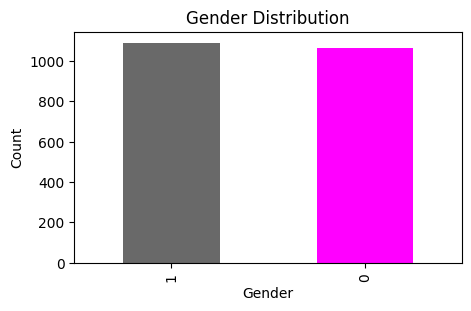

In [ ]:
# Visualize the distribution of 'Gender' variable
print(df.value_counts('Gender'))

plt.figure(figsize=(5, 3))
df['Gender'].value_counts().plot(kind='bar', color=['dimgray', 'magenta'])
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

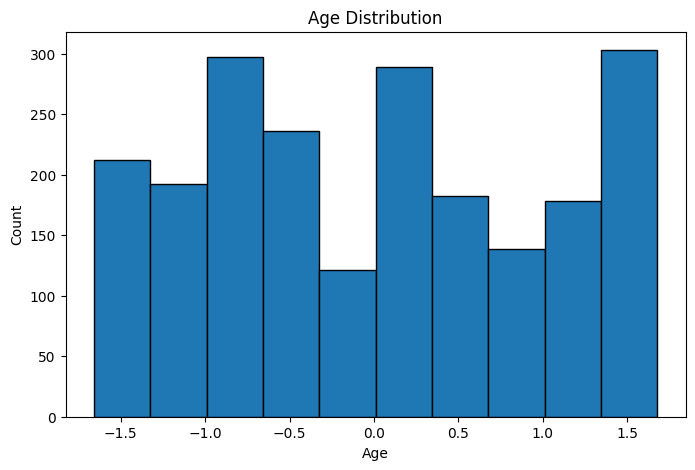

In [ ]:
# Visualize the distribution of 'Age' variable
plt.figure(figsize=(8, 5))
plt.hist(df['Age'].dropna(), edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

<Figure size 600x400 with 0 Axes>

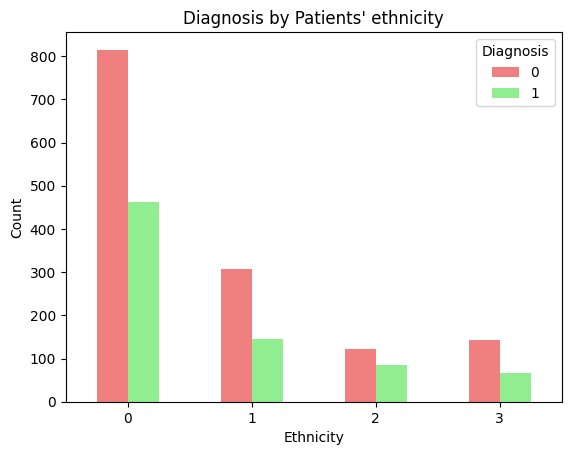

In [ ]:
# Visualize the relationship between 'Ethnicity' and 'Diagnosis'

plt.figure(figsize=(6, 4))
pd.crosstab(df['Ethnicity'], df['Diagnosis']).plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Diagnosis by Patients\' ethnicity')
plt.xlabel('Ethnicity')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


<Figure size 600x400 with 0 Axes>

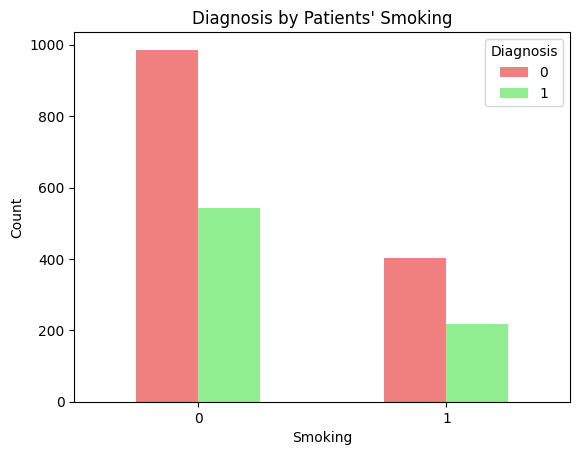

In [ ]:
# Visualize the relationship between 'Smoking' and 'Diagnosis'

plt.figure(figsize=(6, 4))
pd.crosstab(df['Smoking'], df['Diagnosis']).plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Diagnosis by Patients\' Smoking')
plt.xlabel('Smoking')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

<Figure size 600x400 with 0 Axes>

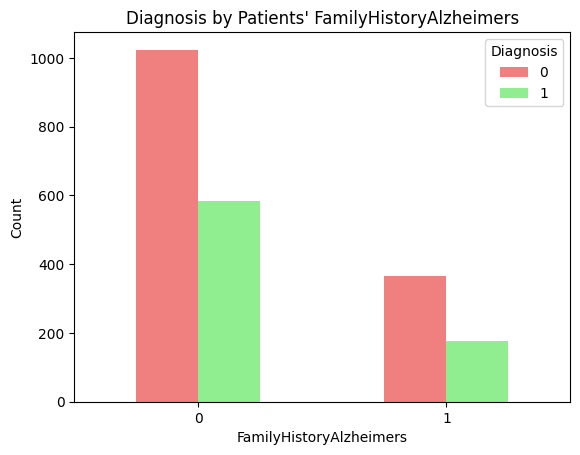

In [ ]:
# Visualize the relationship between 'FamilyHistoryAlzheimers' and 'Diagnosis'

plt.figure(figsize=(6, 4))
pd.crosstab(df['FamilyHistoryAlzheimers'], df['Diagnosis']).plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Diagnosis by Patients\' FamilyHistoryAlzheimers')
plt.xlabel('FamilyHistoryAlzheimers')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


<Figure size 600x400 with 0 Axes>

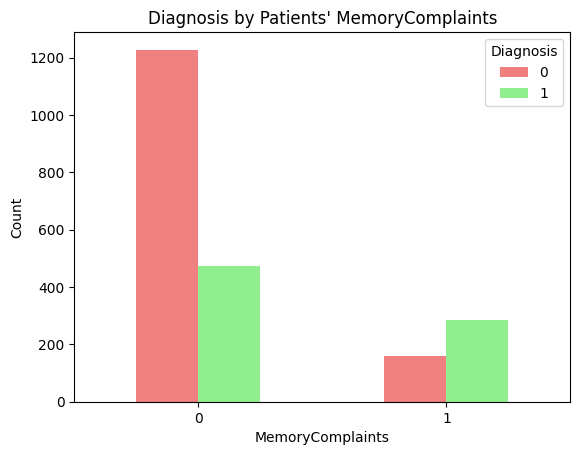

In [ ]:
# Visualize the relationship between 'MemoryComplaints' and 'Diagnosis'

plt.figure(figsize=(6, 4))
pd.crosstab(df['MemoryComplaints'], df['Diagnosis']).plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Diagnosis by Patients\' MemoryComplaints')
plt.xlabel('MemoryComplaints')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


<Figure size 600x400 with 0 Axes>

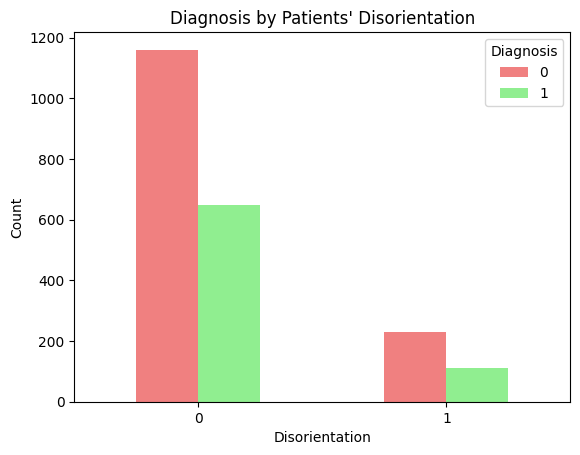

In [ ]:
# Visualize the relationship between 'Disorientation' and 'Diagnosis'

plt.figure(figsize=(6, 4))
pd.crosstab(df['Disorientation'], df['Diagnosis']).plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Diagnosis by Patients\' Disorientation')
plt.xlabel('Disorientation')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

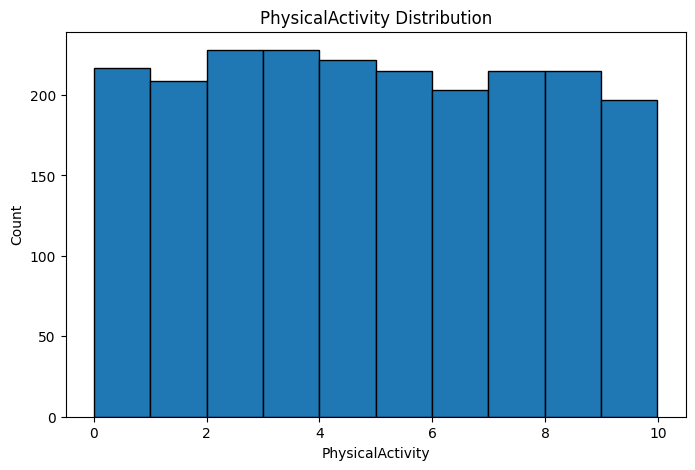

In [ ]:
# Visualize the distribution of 'PhysicalActivity' variable
plt.figure(figsize=(8, 5))
plt.hist(df['PhysicalActivity'].dropna(), edgecolor='black')
plt.title('PhysicalActivity Distribution')
plt.xlabel('PhysicalActivity')
plt.ylabel('Count')
plt.show()


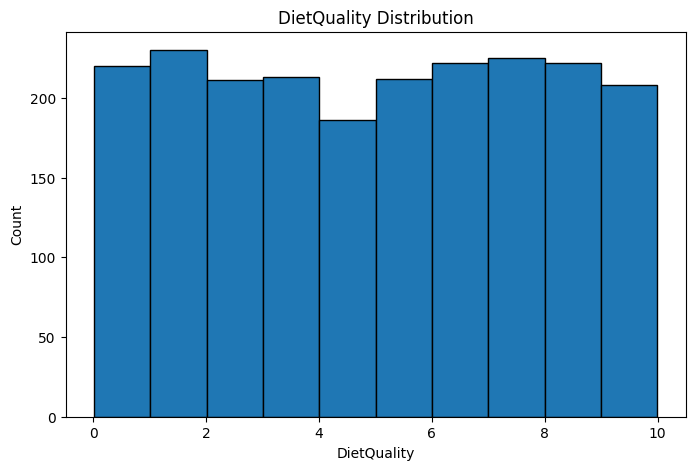

In [ ]:
# Visualize the distribution of 'DietQuality' variable
plt.figure(figsize=(8, 5))
plt.hist(df['DietQuality'].dropna(), edgecolor='black')
plt.title('DietQuality Distribution')
plt.xlabel('DietQuality')
plt.ylabel('Count')
plt.show()


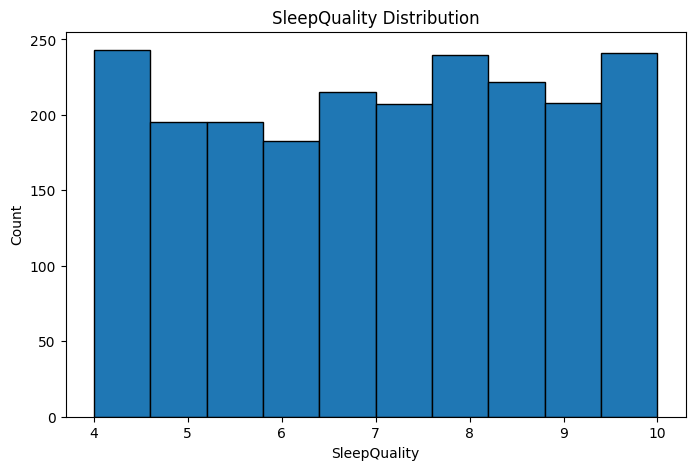

In [ ]:
# Visualize the distribution of 'SleepQuality' variable
plt.figure(figsize=(8, 5))
plt.hist(df['SleepQuality'].dropna(), edgecolor='black')
plt.title('SleepQuality Distribution')
plt.xlabel('SleepQuality')
plt.ylabel('Count')
plt.show()


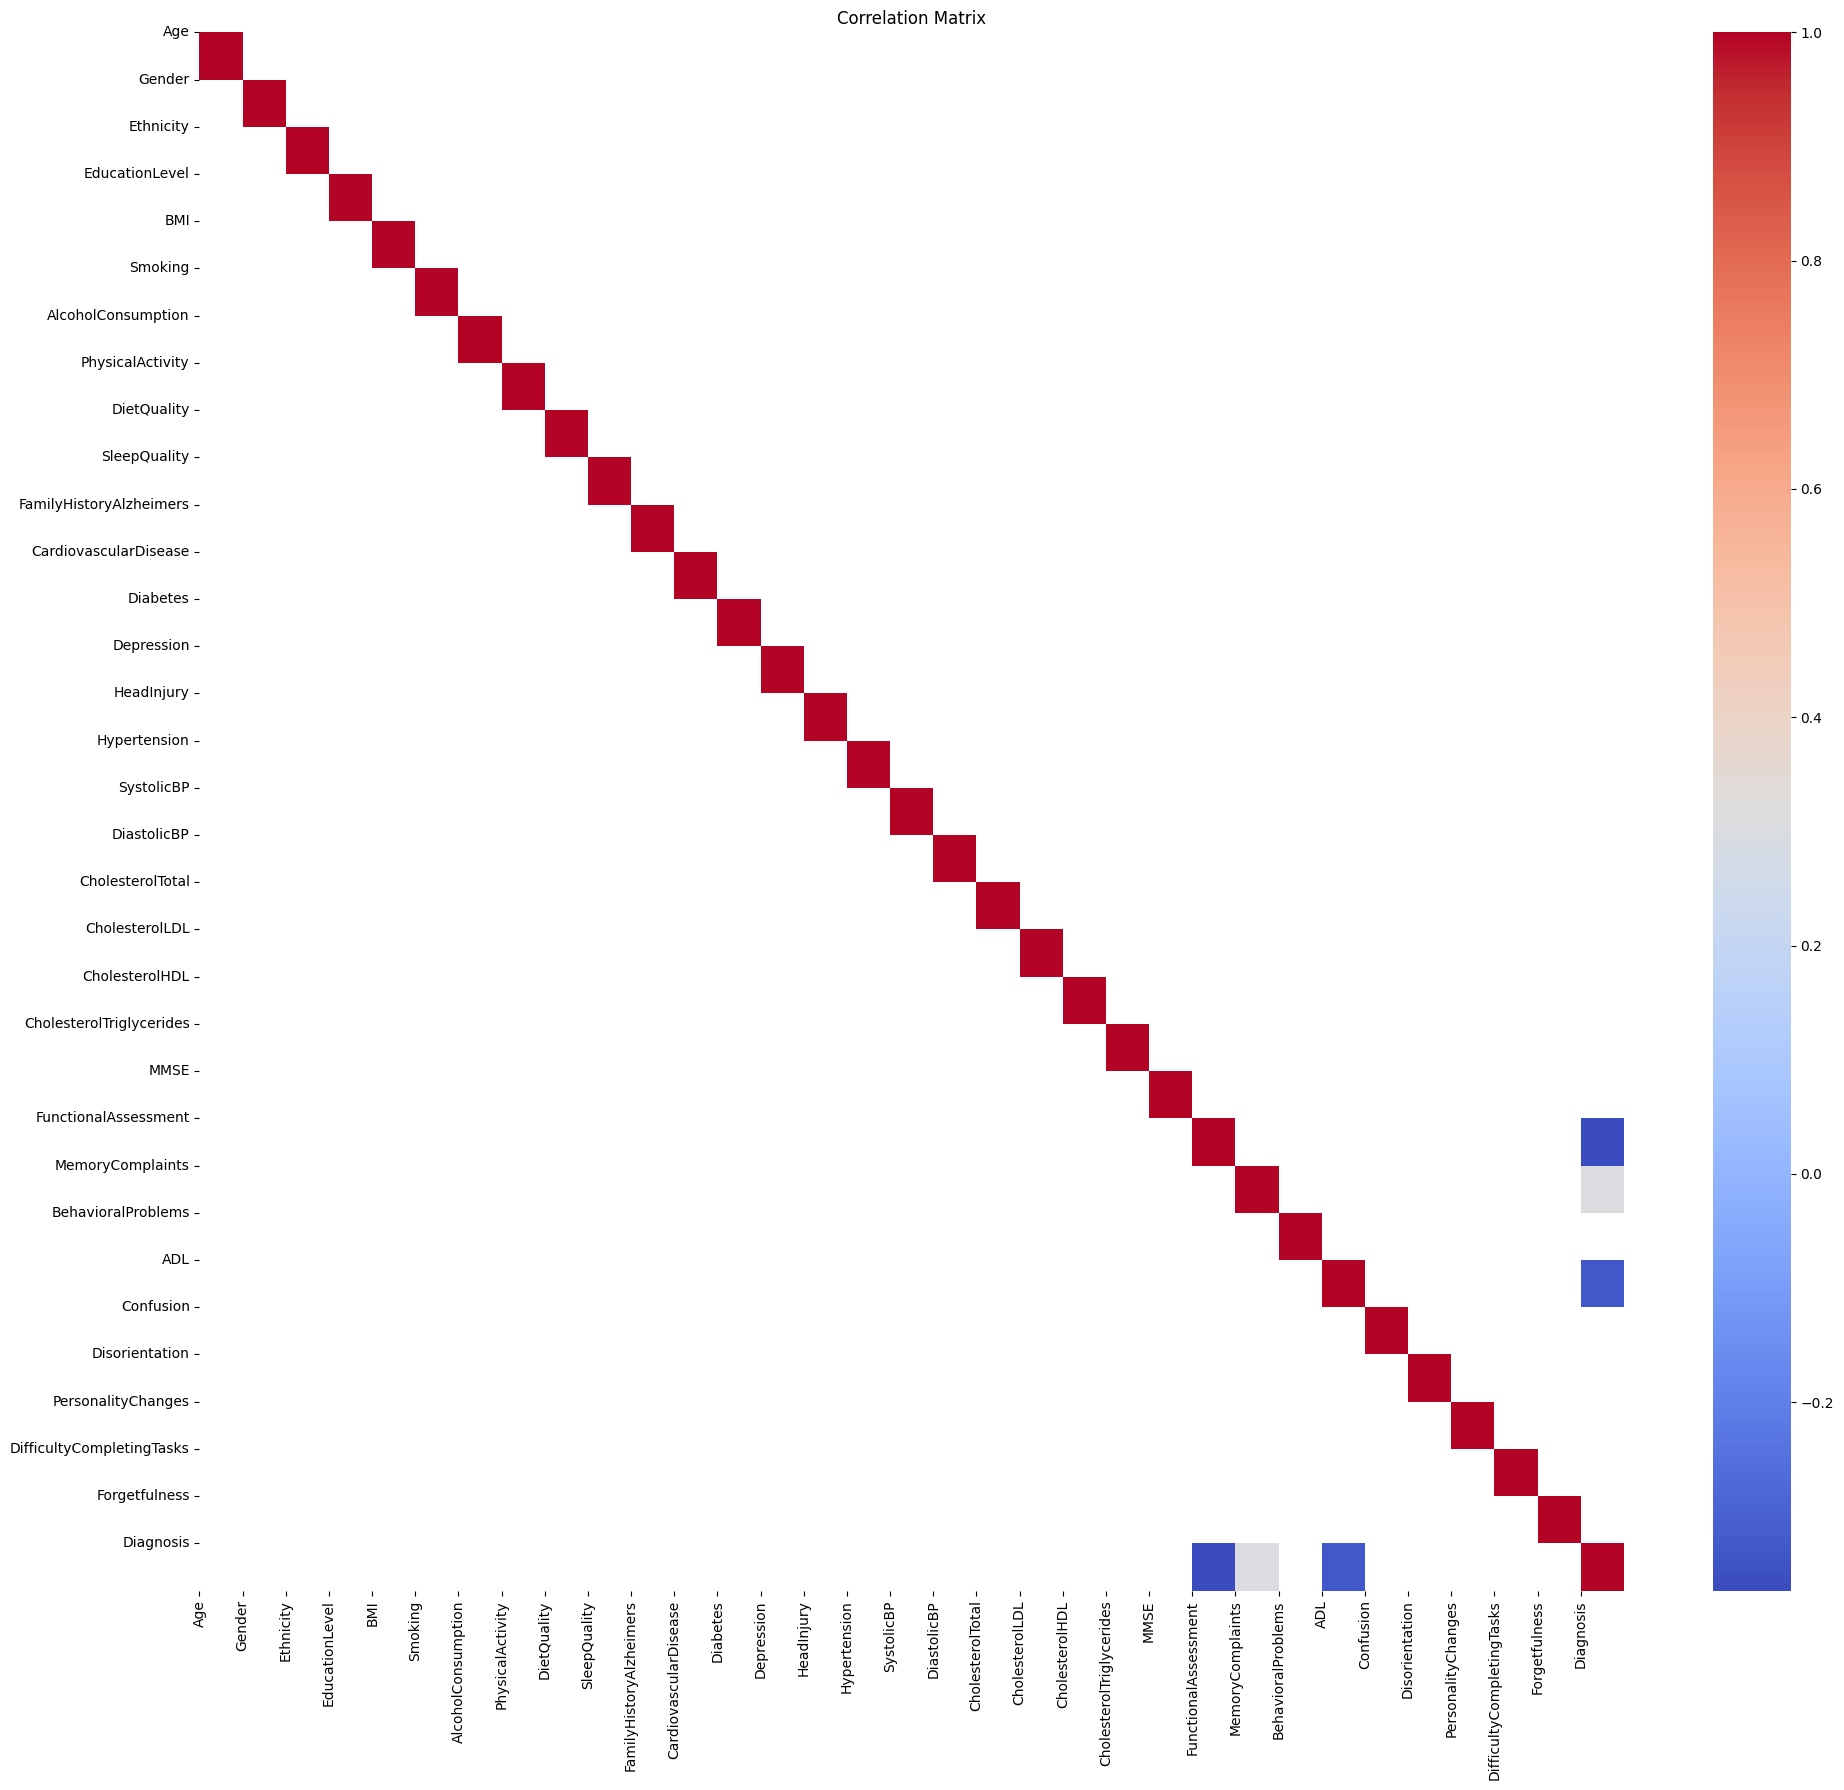

In [ ]:
# Correlation matrix plot
plt.figure(figsize=(20, 18))
correlation_matrix = df.corr(numeric_only=True)
mask = abs(correlation_matrix) >= 0.3
sns.heatmap(correlation_matrix[mask], annot=False, cmap='coolwarm', cbar=True,
            xticklabels=True, yticklabels=True)
plt.title('Correlation Matrix')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.tight_layout()


# Data Preprocessing

In [ ]:
#print(df.columns)
df.shape

(2149, 34)

In [ ]:
df.isnull().sum()
df = df.drop_duplicates()
df

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,-0.212368,0,0,2,-0.655225,0,13.297218,6.327112,1.347214,9.025679,...,0,0,-1.104434,0,0,0,1,0,0,XXXConfid
1,1.567757,0,0,0,-0.114751,0,4.542524,7.619885,0.518767,7.151293,...,0,0,-0.810601,0,0,0,0,1,0,XXXConfid
2,-0.212368,0,3,1,-1.366428,0,19.555085,7.844988,1.826335,9.673574,...,0,0,0.724491,0,1,0,1,0,0,XXXConfid
3,-0.101111,1,0,1,0.851625,1,12.209266,8.428001,7.435604,8.392554,...,0,1,0.508044,0,0,0,0,0,0,XXXConfid
4,1.567757,0,0,0,-0.961607,0,18.454356,6.310461,0.795498,5.597238,...,0,0,-1.684679,0,0,1,1,0,0,XXXConfid
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2144,-1.547463,0,0,1,1.589030,0,1.561126,4.049964,6.555306,7.535540,...,0,0,-0.166194,1,0,0,0,0,1,XXXConfid
2145,0.010147,0,0,2,-1.357833,0,18.767261,1.360667,2.904662,8.555256,...,0,1,1.431627,0,0,0,0,0,1,XXXConfid
2146,0.232663,0,0,1,-1.687864,0,4.594670,9.886002,8.120025,5.769464,...,0,0,0.018099,0,0,0,0,0,1,XXXConfid
2147,0.343921,1,3,1,-1.712334,0,8.674505,6.354282,1.263427,8.322874,...,0,0,-0.406078,0,0,0,0,1,1,XXXConfid


In [ ]:
df = df.drop('DoctorInCharge', axis=1)
# Drop PatientID if it exists
if 'PatientID' in df.columns:
    df = df.drop('PatientID', axis=1)

In [ ]:
#categorical numerical
import numpy as np
categorical_clmn=df.select_dtypes(include=['object']).columns.tolist()
print("categorical colomn:",categorical_clmn)
numeric_colmn = df.select_dtypes(include=np.number).columns.tolist()
print("numeric colomn:",numeric_colmn)
df.head()

categorical colomn: []
numeric colomn: ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'BMI', 'Smoking', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness', 'Diagnosis']


,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,-0.212368,0,0,2,-0.655225,0,13.297218,6.327112,1.347214,9.025679,...,0.497506,0,0,-1.104434,0,0,0,1,0,0
1,1.567757,0,0,0,-0.114751,0,4.542524,7.619885,0.518767,7.151293,...,0.704907,0,0,-0.810601,0,0,0,0,1,0
2,-0.212368,0,3,1,-1.366428,0,19.555085,7.844988,1.826335,9.673574,...,0.281813,0,0,0.724491,0,1,0,1,0,0
3,-0.101111,1,0,1,0.851625,1,12.209266,8.428001,7.435604,8.392554,...,1.343346,0,1,0.508044,0,0,0,0,0,0
4,1.567757,0,0,0,-0.961607,0,18.454356,6.310461,0.795498,5.597238,...,0.333665,0,0,-1.684679,0,0,1,1,0,0


In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [ ]:
# Split into X (features) and y (target)
X = df.drop('Diagnosis', axis=1)  # All input columns
y = df['Diagnosis']               # The column we want to predict

In [ ]:
# Use 80% of data for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_pred_rf = model.predict(X_test)
y_pred_logreg = model.predict(X_test)


# Print results
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
###Added Now
print("True Labels:", y_test.values[:10])
print("Random Forest Predictions:", y_pred_rf[:10])
print("Logistic Regression Predictions:", y_pred_logreg[:10])

Accuracy: 0.9069767441860465

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.94      0.93       277
           1       0.89      0.84      0.87       153

    accuracy                           0.91       430
   macro avg       0.90      0.89      0.90       430
weighted avg       0.91      0.91      0.91       430

Confusion Matrix:
 [[261  16]
 [ 24 129]]
True Labels: [0 0 0 0 0 0 1 0 0 1]
Random Forest Predictions: [0 0 1 0 0 0 1 1 0 1]
Logistic Regression Predictions: [0 0 1 0 0 0 1 1 0 1]


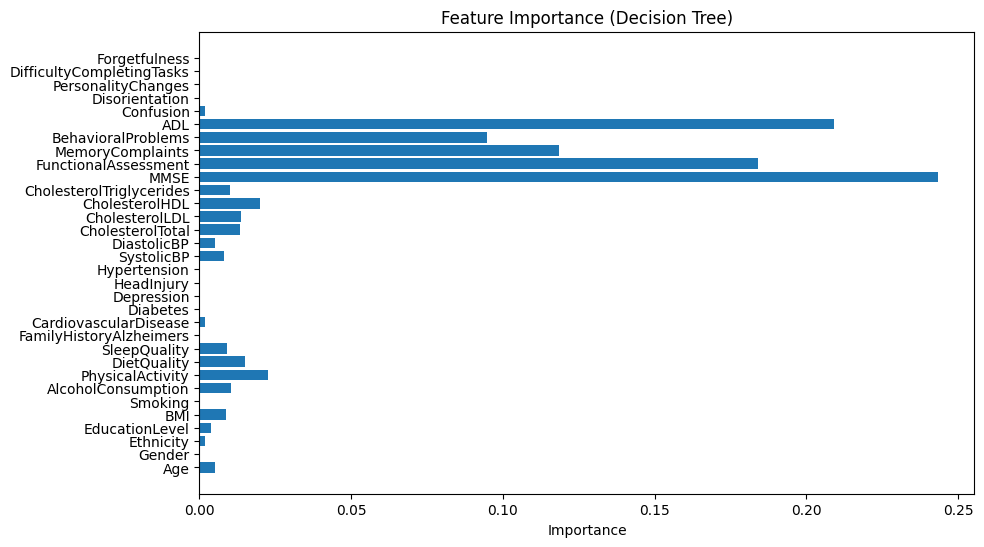

In [ ]:
# Show which features matter most
importances = model.feature_importances_
feature_names = X.columns

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.xlabel("Importance")
plt.title("Feature Importance (Decision Tree)")
plt.show()

RANDOM FOREST

Random Forest Accuracy: 0.9255813953488372
True Labels: [0 0 0 0 0 0 1 0 0 1]
Random Forest Predictions: [0 0 0 0 0 0 1 0 0 1]
Logistic Regression Predictions: [0 0 1 0 0 0 1 1 0 1]
Random Forest Accuracy (immediate): 0.9255813953488372


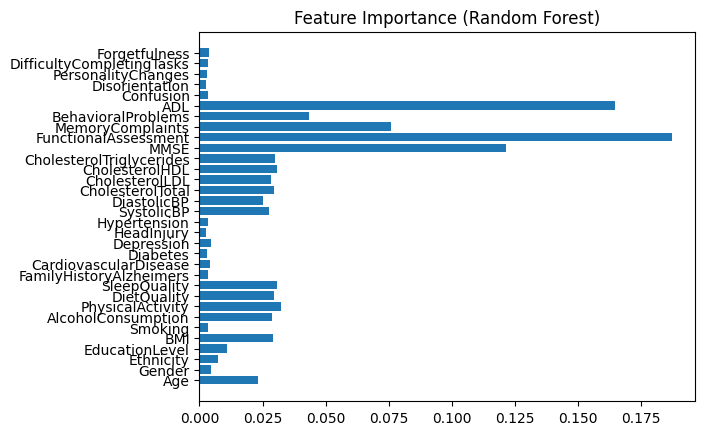

In [ ]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

######Added Now

print("True Labels:", y_test.values[:10])
print("Random Forest Predictions:", y_pred_rf[:10])
print("Logistic Regression Predictions:", y_pred_logreg[:10])


# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy (immediate):", accuracy_score(y_test, y_pred_rf))

###Graph
importances = rf_model.feature_importances_
plt.barh(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()


LOGISTIC REGRESSION

Logistic Regression Accuracy: 0.8302325581395349

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87       277
           1       0.79      0.71      0.75       153

    accuracy                           0.83       430
   macro avg       0.82      0.80      0.81       430
weighted avg       0.83      0.83      0.83       430

Confusion Matrix:
 [[248  29]
 [ 44 109]]
True Labels: [0 0 0 0 0 0 1 0 0 1]
Random Forest Predictions: [0 0 0 0 0 0 1 0 0 1]
Logistic Regression Predictions: [0 0 0 0 0 0 1 0 0 1]
Logistic Regression Accuracy (immediate): 0.8302325581395349


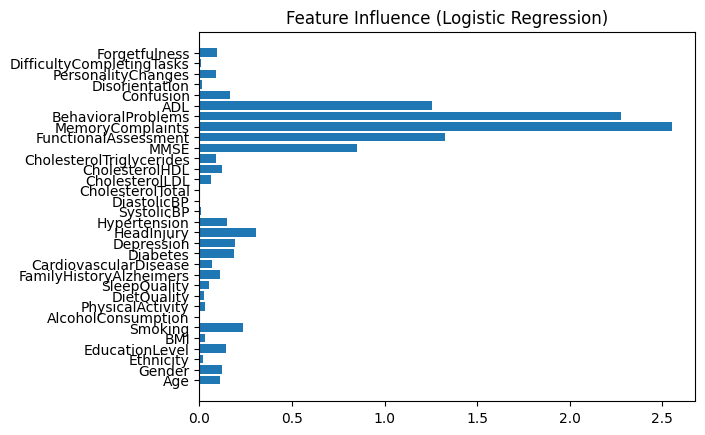

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_logreg = log_reg_model.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_logreg))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg))


#####ADDED NOW
print("True Labels:", y_test.values[:10])
print("Random Forest Predictions:", y_pred_rf[:10])
print("Logistic Regression Predictions:", y_pred_logreg[:10])
######
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train, y_train)
y_pred_logreg = log_reg_model.predict(X_test)
print("Logistic Regression Accuracy (immediate):", accuracy_score(y_test, y_pred_logreg))

######Graph
importances = np.abs(log_reg_model.coef_[0])
plt.barh(feature_names, importances)
plt.title("Feature Influence (Logistic Regression)")
plt.show()


Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC

# Initialize and train the model
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

#####Added
print("True Labels:", y_test.values[:10])
print("Random Forest Predictions:", y_pred_rf[:10])
print("Logistic Regression Predictions:", y_pred_logreg[:10])

SVM Accuracy: 0.6441860465116279

Classification Report:
               precision    recall  f1-score   support

           0       0.64      1.00      0.78       277
           1       0.00      0.00      0.00       153

    accuracy                           0.64       430
   macro avg       0.32      0.50      0.39       430
weighted avg       0.41      0.64      0.50       430

Confusion Matrix:
 [[277   0]
 [153   0]]
True Labels: [0 0 0 0 0 0 1 0 0 1]
Random Forest Predictions: [0 0 0 0 0 0 1 0 0 1]
Logistic Regression Predictions: [0 0 0 0 0 0 1 0 0 1]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Ensemble Method

Ensemble Accuracy: 0.9279069767441861

 Ensemble (Voting) Accuracy: 0.9279

 Final Model Accuracy Comparison:
+---------------------+------------+
| Model               |   Accuracy |
+=====================+============+
| Decision Tree       |   0.906977 |
+---------------------+------------+
| Random Forest       |   0.925581 |
+---------------------+------------+
| Logistic Regression |   0.830233 |
+---------------------+------------+
| SVM                 |   0.644186 |
+---------------------+------------+
| Ensemble (Voting)   |   0.927907 |
+---------------------+------------+

 Top 10 Features and Their Most Influential Model:
+--------------------------+-----------------+-----------------+-----------------------+-------+---------------------+
| index                    |   Decision Tree |   Random Forest |   Logistic Regression |   SVM | Most Important In   |
+==========================+=================+=================+=======================+=======+=====================+


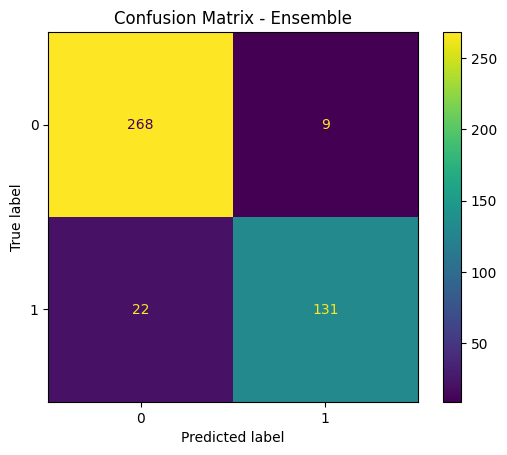

In [ ]:
from tabulate import tabulate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
 #------------------ Ensemble Model ------------------
voting_clf = VotingClassifier(
    estimators=[
        ('Decision Tree', model),
        ('Random Forest', rf_model),
        ('Logistic Regression', log_reg_model)
    ],
    voting='soft'   # Use 'soft' if all models support predict_proba
)
voting_clf.fit(X_train, y_train)
y_pred_ensemble = voting_clf.predict(X_test)
y_pred_svm = svm_model.predict(X_test)
print("Ensemble Accuracy:", accuracy_score(y_test, y_pred_ensemble))

ensemble_accuracy = accuracy_score(y_test, y_pred_ensemble)
print(f"\n Ensemble (Voting) Accuracy: {ensemble_accuracy:.4f}")

# ---------------------------------------
# Accuracy Table Using Existing Predictions
# ---------------------------------------
accuracies = {
    "Decision Tree": accuracy_score(y_test, y_pred),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Logistic Regression": accuracy_score(y_test, y_pred_logreg),
    "SVM": accuracy_score(y_test, y_pred_svm),
    "Ensemble (Voting)": accuracy_score(y_test, y_pred_ensemble)
}

accuracy_df = pd.DataFrame(list(accuracies.items()), columns=["Model", "Accuracy"])
print("\n Final Model Accuracy Comparison:")
print(tabulate(accuracy_df, headers="keys", tablefmt="grid", showindex=False))

# ---------------------------------------
# Feature Importance Comparison
# ---------------------------------------
feature_scores = pd.DataFrame(index=X.columns)

# Decision Tree
feature_scores["Decision Tree"] = model.feature_importances_

# Random Forest
feature_scores["Random Forest"] = rf_model.feature_importances_

# Logistic Regression (absolute values of coefficients)
feature_scores["Logistic Regression"] = np.abs(log_reg_model.coef_[0])

# SVM doesn't provide feature importance
feature_scores["SVM"] = np.nan

# Model that considers each feature most important
feature_scores["Most Important In"] = feature_scores[
    ["Decision Tree", "Random Forest", "Logistic Regression"]
].idxmax(axis=1)

# Display Top 10 Features
top_features = feature_scores.sort_values(by="Random Forest", ascending=False).reset_index()
print("\n Top 10 Features and Their Most Influential Model:")
print(tabulate(top_features.head(10), headers="keys", tablefmt="grid", showindex=False))

###Adding a Confusion Matrix to Show where the Model makes Mistake
cm = confusion_matrix(y_test, y_pred_ensemble)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Ensemble")
plt.show()

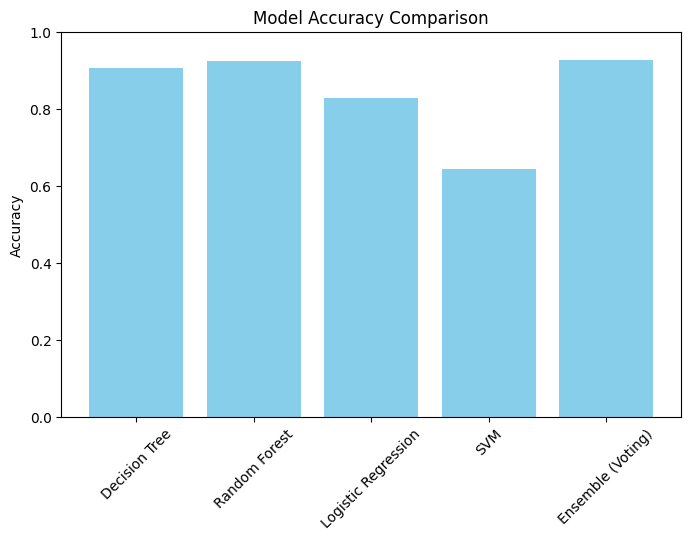

In [ ]:
#Visual Comparison of Accuracies
plt.figure(figsize=(8,5))
plt.bar(accuracy_df['Model'], accuracy_df['Accuracy'], color='skyblue')
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


In [ ]:
#Cross-validation for robustness
from sklearn.model_selection import cross_val_score

scores = cross_val_score(voting_clf, X, y, cv=5)
print("Cross-validated scores:", scores)
print("Mean Accuracy:", scores.mean())


Cross-validated scores: [0.95581395 0.95116279 0.95813953 0.96046512 0.7972028 ]
Mean Accuracy: 0.9245568385103269
